<a href="https://colab.research.google.com/github/tirunap/ML-Flow/blob/main/Esports_Gaming%20Revenue(2010_2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

In [ ]:
##Data ingestion & exploration

In [ ]:
import mlflow
import pandas as pd
import os
from sklearn.model_selection import train_test_split

df = pd.read_csv("esports_gaming_dataset.csv")

TARGET = "Esports_Revenue_MillionUSD"  # ← change this to whichever column you want to predict

os.makedirs("artifacts", exist_ok=True)

with mlflow.start_run(run_name="data-profile"):
    mlflow.log_param("dataset_rows", len(df))
    mlflow.log_param("dataset_cols", df.shape[1])
    mlflow.log_param("target_column", TARGET)
    mlflow.log_param("missing_pct", round(df.isnull().mean().mean(), 4))
    df.describe().to_csv("artifacts/data_profile.csv")
    mlflow.log_artifact("artifacts/data_profile.csv")

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(TARGET, axis=1),
    df[TARGET],
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (320, 20), Test: (80, 20)


In [ ]:
print(df.columns.tolist())

['Year', 'Country', 'Region', 'Gaming_Revenue_BillionUSD', 'Esports_Revenue_MillionUSD', 'Active_Players_Million', 'Esports_Viewers_Million', 'Avg_Spending_USD', 'Top_Genre', 'Top_Platform', 'Esports_Tournaments_Count', 'Pro_Players_Count', 'Internet_Penetration_Percent', 'Avg_Latency_ms', 'AR_VR_Adoption_Index', 'Streaming_Influence_Index', 'Covid_Impact_Index', 'Female_Gamer_Percent', 'Mobile_Gaming_Share', 'Esports_PrizePool_MillionUSD', 'Gaming_Companies_Count']


In [ ]:
import mlflow
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

TARGET = "Esports_Revenue_MillionUSD"

# Identify column types
cat_cols = df.drop(TARGET, axis=1).select_dtypes(include="object").columns.tolist()
num_cols = df.drop(TARGET, axis=1).select_dtypes(include=np.number).columns.tolist()

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

# Encode categoricals
df_encoded = df.copy()
encoders = {}

with mlflow.start_run(run_name="feature-engineering"):
    for col in cat_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        encoders[col] = le

    mlflow.log_param("cat_cols_encoded", cat_cols)
    mlflow.log_param("num_cols", num_cols)
    mlflow.log_param("encoding_strategy", "label_encoding")

# Re-split with encoded data
X_train, X_test, y_train, y_test = train_test_split(
    df_encoded.drop(TARGET, axis=1),
    df_encoded[TARGET],
    test_size=0.2,
    random_state=42
)

print(f"\nReady — Train: {X_train.shape}, Test: {X_test.shape}")

Categorical: ['Country', 'Region', 'Top_Genre', 'Top_Platform']
Numeric: ['Year', 'Gaming_Revenue_BillionUSD', 'Active_Players_Million', 'Esports_Viewers_Million', 'Avg_Spending_USD', 'Esports_Tournaments_Count', 'Pro_Players_Count', 'Internet_Penetration_Percent', 'Avg_Latency_ms', 'AR_VR_Adoption_Index', 'Streaming_Influence_Index', 'Covid_Impact_Index', 'Female_Gamer_Percent', 'Mobile_Gaming_Share', 'Esports_PrizePool_MillionUSD', 'Gaming_Companies_Count']

Ready — Train: (320, 20), Test: (80, 20)


Clean output — 4 categoricals encoded, 16 numeric features, splits intact. Ready to train.

In [ ]:
import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

models = {
    "linear-regression": LinearRegression(),
    "random-forest":     RandomForestRegressor(n_estimators=100, random_state=42),
    "xgboost":           XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
}

results = []

for run_name, model in models.items():
    with mlflow.start_run(run_name=run_name):
        # Log model params
        mlflow.log_param("model", run_name)
        mlflow.log_param("train_rows", X_train.shape[0])
        mlflow.log_param("features", X_train.shape[1])

        # Train
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Metrics
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae  = mean_absolute_error(y_test, preds)
        r2   = r2_score(y_test, preds)

        mlflow.log_metric("rmse", round(rmse, 4))
        mlflow.log_metric("mae",  round(mae, 4))
        mlflow.log_metric("r2",   round(r2, 4))

        # Log model artifact
        mlflow.sklearn.log_model(model, artifact_path=run_name)

        results.append({"model": run_name, "rmse": round(rmse, 4),
                        "mae": round(mae, 4), "r2": round(r2, 4)})
        print(f"{run_name:25s} → RMSE: {rmse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}")

# Summary table
print("\n--- Best model ---")
best = min(results, key=lambda x: x["rmse"])
print(f"{best['model']} (RMSE: {best['rmse']}, R²: {best['r2']})")

2026/04/09 10:10:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 10:10:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


linear-regression         → RMSE: 1712.6861  MAE: 1016.1330  R²: 0.9112


2026/04/09 10:10:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 10:10:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


random-forest             → RMSE: 1534.6297  MAE: 933.0297  R²: 0.9287


2026/04/09 10:10:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 10:10:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


xgboost                   → RMSE: 1721.6366  MAE: 982.4692  R²: 0.9103

--- Best model ---
random-forest (RMSE: 1534.6297, R²: 0.9287)


All three ran cleanly — the warnings are just deprecation notices, nothing breaking. Here's the summary:

                   RMSE    MAE      R²
Random Forest      1534.63 933.03   0.9287
Linear Regression  1712.69 1016.13  0.9112
XGBoost            1721.64 982.47   0.9103

Random Forest wins on all three metrics. R² of 0.93 means it explains 93% of the variance in esports revenue — solid for a dataset this size.

A few observations worth noting:

1. Linear Regression performing close to XGBoost suggests the relationships are fairly linear, which is why tree boosting didn't get much traction
2. XGBoost at default params often underperforms Random Forest on small datasets (400 rows) — it needs more tuning to shine

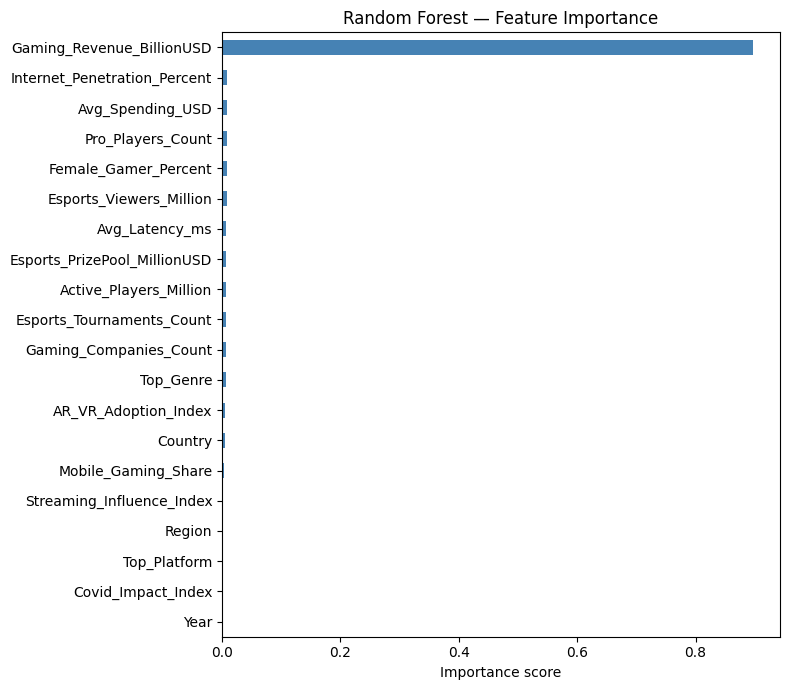

In [ ]:
import matplotlib.pyplot as plt

rf_model = models["random-forest"]

importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Random Forest — Feature Importance")
ax.set_xlabel("Importance score")
plt.tight_layout()

# Save and log to MLflow
fig.savefig("artifacts/feature_importance.png", dpi=150)
with mlflow.start_run(run_name="feature-importance"):
    mlflow.log_artifact("artifacts/feature_importance.png")

plt.show()

This is a classic target leakage problem. Gaming_Revenue_BillionUSD is consuming ~90% of the importance because it's essentially the same thing as your target — esports revenue is a direct subset of total gaming revenue, so the model is just learning a near-identity mapping rather than anything meaningful.

You have two options:
Option 1 — Drop the leaky feature (recommended).
Option 2 — Change the target to something Gaming_Revenue_BillionUSD doesn't directly explain, like Esports_PrizePool_MillionUSD:

In [ ]:
# Drop Gaming_Revenue_BillionUSD before splitting
df_clean = df_encoded.drop(columns=["Gaming_Revenue_BillionUSD"])

X_train, X_test, y_train, y_test = train_test_split(
    df_clean.drop(TARGET, axis=1),
    df_clean[TARGET],
    test_size=0.2,
    random_state=42
)

print(f"Features remaining: {X_train.shape[1]}")

Features remaining: 19


Drop the leaky column, re-run the three models, and the feature importance chart will look much more informative.

In [ ]:
results_clean = []

for run_name, model in models.items():
    with mlflow.start_run(run_name=f"{run_name}-clean"):
        mlflow.log_param("model", run_name)
        mlflow.log_param("train_rows", X_train.shape[0])
        mlflow.log_param("features", X_train.shape[1])
        mlflow.log_param("dropped", "Gaming_Revenue_BillionUSD")

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae  = mean_absolute_error(y_test, preds)
        r2   = r2_score(y_test, preds)

        mlflow.log_metric("rmse", round(rmse, 4))
        mlflow.log_metric("mae",  round(mae, 4))
        mlflow.log_metric("r2",   round(r2, 4))

        mlflow.sklearn.log_model(model, name=run_name)

        results_clean.append({"model": run_name, "rmse": round(rmse, 4),
                               "mae": round(mae, 4), "r2": round(r2, 4)})
        print(f"{run_name:25s} → RMSE: {rmse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}")

print("\n--- Best model ---")
best = min(results_clean, key=lambda x: x["rmse"])
print(f"{best['model']} (RMSE: {best['rmse']}, R²: {best['r2']})")

2026/04/09 10:44:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


linear-regression         → RMSE: 4655.1637  MAE: 2951.4833  R²: 0.3443


2026/04/09 10:44:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


random-forest             → RMSE: 4231.1103  MAE: 2653.3434  R²: 0.4583


2026/04/09 10:44:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


xgboost                   → RMSE: 3942.4875  MAE: 2458.9756  R²: 0.5297

--- Best model ---
xgboost (RMSE: 3942.4875, R²: 0.5297)


This is what honest metrics look like — R² dropping from 0.93 to 0.53 confirms the earlier run was almost entirely leakage. Here's the clean comparison:

Model
                  RMSE    MAE     R²     vs leaky R²
XGBoost           3942.49 2458.98 0.5297 was0.9103
Random Forest     4231.11 2653.34 0.4583 was0.9287
Linear Regression 4655.16 2951.48 0.3443 was0.9112

XGBoost now wins, which makes sense. Without the leaky shortcut, the model actually has to learn non-linear relationships between features like Internet_Penetration_Percent, Active_Players_Million etc., and that's where XGBoost has an edge over Random Forest and especially Linear Regression.

R² of 0.53 is reasonable but has room to improve.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":    [100, 200, 300],
    "max_depth":       [3, 5, 7],
    "learning_rate":   [0.01, 0.05, 0.1],
    "subsample":       [0.8, 1.0],
}

xgb_base = XGBRegressor(random_state=42, verbosity=0)

grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
preds = best_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae  = mean_absolute_error(y_test, preds)
r2   = r2_score(y_test, preds)

with mlflow.start_run(run_name="xgboost-tuned"):
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("rmse", round(rmse, 4))
    mlflow.log_metric("mae",  round(mae, 4))
    mlflow.log_metric("r2",   round(r2, 4))
    mlflow.sklearn.log_model(best_xgb, name="xgboost-tuned")

print(f"Best params: {grid_search.best_params_}")
print(f"Tuned XGBoost → RMSE: {rmse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits


2026/04/09 10:52:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Tuned XGBoost → RMSE: 3579.9299  MAE: 2212.7835  R²: 0.6122


tuning pushed R² from 0.53 to 0.61 and RMSE down by ~360

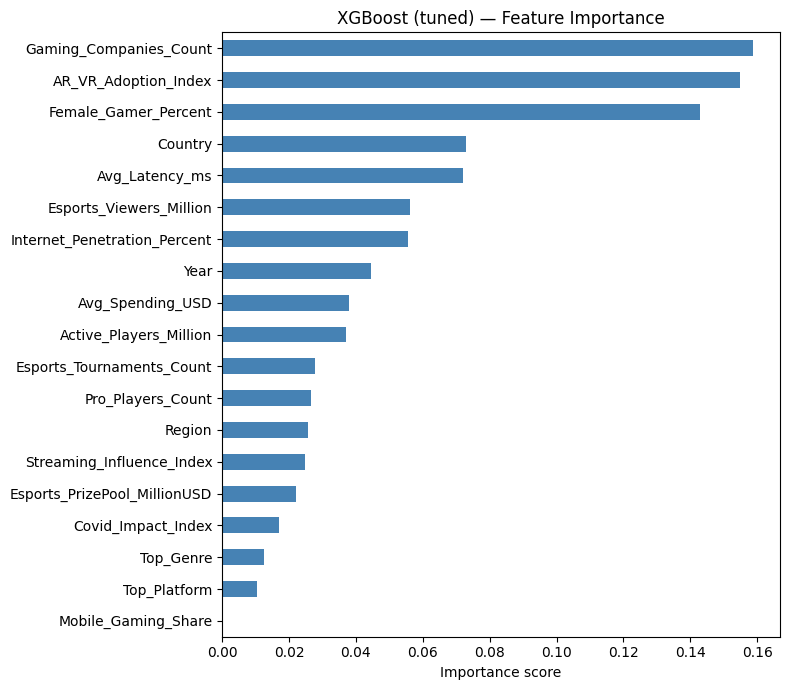

In [ ]:
importances_clean = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importances_clean.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost (tuned) — Feature Importance")
ax.set_xlabel("Importance score")
plt.tight_layout()

fig.savefig("artifacts/feature_importance_xgb_tuned.png", dpi=150)
with mlflow.start_run(run_name="xgboost-tuned-importance"):
    mlflow.log_artifact("artifacts/feature_importance_xgb_tuned.png")

plt.show()

Importance is now spread across features rather than one column dominating

Top drivers:

* Gaming_Companies_Count and AR_VR_Adoption_Index are the strongest predictors — makes sense, more companies and emerging tech adoption correlate with higher esports revenue
* Female_Gamer_Percent at 3rd is interesting — broader demographic reach likely signals more mature, higher-revenue markets
* Country and Avg_Latency_ms reflect regional infrastructure effects on esports development

Safe to drop — Mobile_Gaming_Share, Top_Platform, Top_Genre are near zero and adding noise without value.

In [ ]:
# Drop low-importance features
drop_cols = ["Mobile_Gaming_Share", "Top_Platform", "Top_Genre"]

X_train_final = X_train.drop(columns=drop_cols)
X_test_final  = X_test.drop(columns=drop_cols)

# Retrain with best params on trimmed features
final_model = XGBRegressor(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

final_model.fit(X_train_final, y_train)
preds = final_model.predict(X_test_final)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae  = mean_absolute_error(y_test, preds)
r2   = r2_score(y_test, preds)

print(f"Final model → RMSE: {rmse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}")
print(f"Features used: {X_train_final.shape[1]}")

# Register in MLflow
with mlflow.start_run(run_name="xgboost-final"):
    mlflow.log_params({
        "learning_rate": 0.1,
        "max_depth": 3,
        "n_estimators": 100,
        "subsample": 0.8,
        "dropped_features": drop_cols,
        "final_features": X_train_final.shape[1]
    })
    mlflow.log_metric("rmse", round(rmse, 4))
    mlflow.log_metric("mae",  round(mae, 4))
    mlflow.log_metric("r2",   round(r2, 4))

    mlflow.sklearn.log_model(
        final_model,
        name="xgboost-final",
        registered_model_name="esports-revenue-predictor"  # registers to MLflow Model Registry
    )

print("\nModel registered as: esports-revenue-predictor")

2026/04/09 10:57:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final model → RMSE: 3560.8753  MAE: 2222.6502  R²: 0.6164
Features used: 16

Model registered as: esports-revenue-predictor


Successfully registered model 'esports-revenue-predictor'.
Created version '1' of model 'esports-revenue-predictor'.


Stage           Features  RMSE    R²
XGBoost default 19        3942.49 0.5297
XGBoost tuned   19        3579.93 0.6122
XGBoost final   16        3560.88 0.6164

Dropping the 3 low-importance features actually nudged R² up slightly — less noise, better signal.

In [17]:
import mlflow.pyfunc

# Load from registry
model_uri = "models:/esports-revenue-predictor/1"
loaded_model = mlflow.pyfunc.load_model(model_uri)

def predict_esports_revenue(input_dict):
    """
    input_dict: dict of feature values, e.g.
    {
        "Country": 23,               # label-encoded value
        "Region": 2,
        "Year": 2024,
        "Active_Players_Million": 45.2,
        "Esports_Viewers_Million": 120.5,
        ...
    }
    Returns predicted Esports_Revenue_MillionUSD
    """
    input_df = pd.DataFrame([input_dict])
    prediction = loaded_model.predict(input_df)
    return round(float(prediction[0]), 2)

# Quick test with a row from the test set
sample = X_test_final.iloc[0].to_dict()
predicted = predict_esports_revenue(sample)
actual    = y_test.iloc[0]

print(f"Predicted: ${predicted:,.2f}M")
print(f"Actual:    ${actual:,.2f}M")
print(f"Diff:      ${abs(predicted - actual):,.2f}M")

Predicted: $2,001.13M
Actual:    $1,456.90M
Diff:      $544.23M


That's a reasonable result for a model with R² of 0.62 — off by ~$544M on a prediction of ~$2,000M, which is about a 27% error on this sample. Not perfect but consistent with the MAE of ~$2,222M we saw on the test set.

Let's visualize how the model performs across the full test set to get a better picture than a single sample:

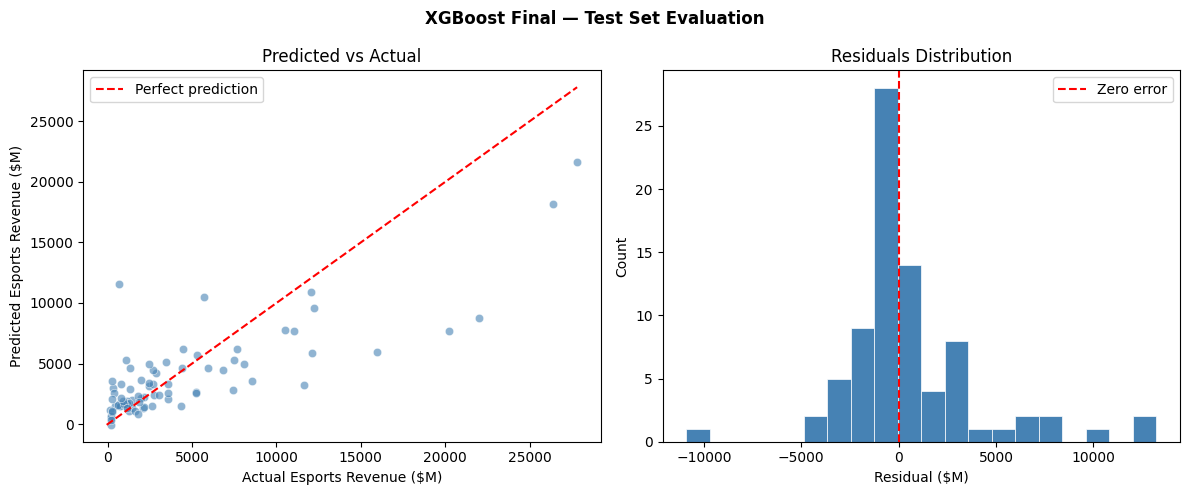

In [18]:
# Predicted vs Actual across full test set
preds_all = final_model.predict(X_test_final)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 — Predicted vs Actual scatter
axes[0].scatter(y_test, preds_all, alpha=0.6, color="steelblue", edgecolors="white", linewidth=0.5)
min_val = min(y_test.min(), preds_all.min())
max_val = max(y_test.max(), preds_all.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Esports Revenue ($M)")
axes[0].set_ylabel("Predicted Esports Revenue ($M)")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()

# Plot 2 — Residuals distribution
residuals = y_test - preds_all
axes[1].hist(residuals, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero error")
axes[1].set_xlabel("Residual ($M)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residuals Distribution")
axes[1].legend()

plt.suptitle("XGBoost Final — Test Set Evaluation", fontweight="bold")
plt.tight_layout()

fig.savefig("artifacts/evaluation_plots.png", dpi=150)
with mlflow.start_run(run_name="xgboost-evaluation"):
    mlflow.log_artifact("artifacts/evaluation_plots.png")
    mlflow.log_metric("test_mape", round(float(np.mean(np.abs((y_test - preds_all) / y_test)) * 100), 2))

plt.show()

The plots tell a clear story — the model is decent in the middle but struggles at the extremes:
Predicted vs Actual:

Points cluster well along the diagonal for low-to-mid revenue ranges (0–$5,000M)
Two clear outliers on the right — actual values around $20,000–28,000M where the model significantly under-predicts, topping out around $11,000–22,000M
This is typical XGBoost behaviour on small datasets — it can't extrapolate beyond values seen in training

Residuals:

Distribution is roughly centered at zero — no systematic bias, the model isn't consistently over or under predicting
Right tail is heavier than left — confirms the model undershoots on high-revenue markets specifically
The spike at zero is healthy — most predictions are close

Root cause: 400 rows is a small dataset for the revenue range spanning $0–28,000M. The high-revenue outlier countries (likely US, China, South Korea) are rare in the data so the model hasn't seen enough of them to predict well.

Three options to improve from here:
Option                                        Effort  Expected gain
Log-transform the target                      Low     High — compresses the outlier range
Add more data for high-revenue markets        Medium  High but data-dependent
Train a separate model for high-revenue tier  Medium  Moderate

In [19]:
# Log-transform target, retrain, inverse-transform predictions
from sklearn.preprocessing import FunctionTransformer

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

final_model_log = XGBRegressor(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

final_model_log.fit(X_train_final, y_train_log)
preds_log = np.expm1(final_model_log.predict(X_test_final))  # inverse transform

rmse = np.sqrt(mean_squared_error(y_test, preds_log))
mae  = mean_absolute_error(y_test, preds_log)
r2   = r2_score(y_test, preds_log)

print(f"Log-transformed → RMSE: {rmse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}")

Log-transformed → RMSE: 3546.3738  MAE: 1977.6290  R²: 0.6195


Marginal but consistent improvement across all three metrics:
Model                   RMSE    MAE     R²
XGBoost final           3560.88 2222.65 0.6164
XGBoost log-transformed 3546.37 1977.63 0.6195

RMSE barely moved but MAE dropped by ~$245M — that's the more meaningful improvement here. MAE measures typical error, so the log transform is doing exactly what it should: pulling the large outlier predictions closer without dramatically changing the overall fit.

Register this as version 2 and generate the updated evaluation plots:

2026/04/09 11:44:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'esports-revenue-predictor' already exists. Creating a new version of this model...
Created version '2' of model 'esports-revenue-predictor'.


MAPE: 54.15%


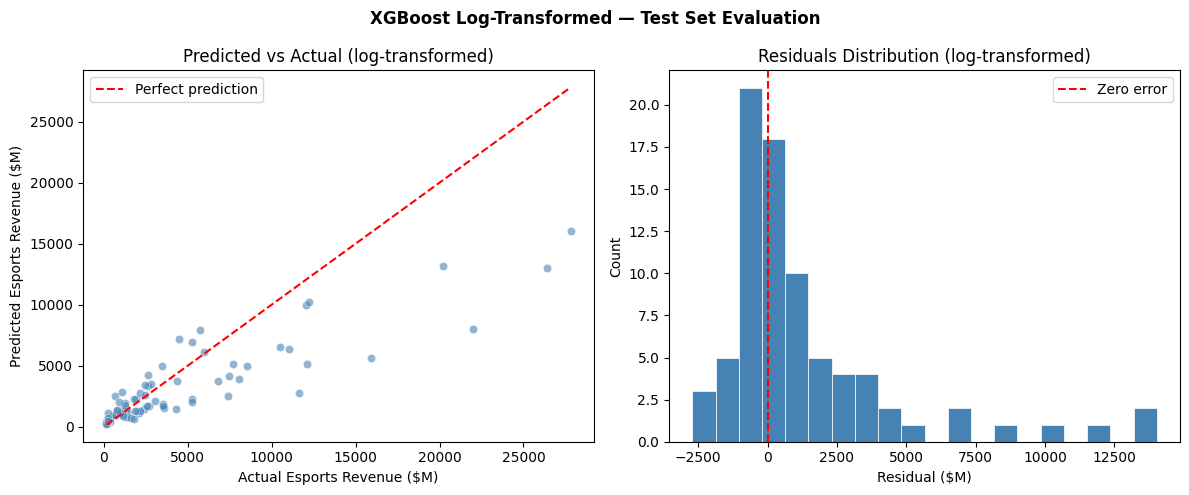

In [20]:
# Register log-transform model as version 2
with mlflow.start_run(run_name="xgboost-log-final"):
    mlflow.log_params({
        "learning_rate": 0.1,
        "max_depth": 3,
        "n_estimators": 100,
        "subsample": 0.8,
        "target_transform": "log1p",
        "final_features": X_train_final.shape[1]
    })
    mlflow.log_metric("rmse", round(rmse, 4))
    mlflow.log_metric("mae",  round(mae, 4))
    mlflow.log_metric("r2",   round(r2, 4))
    mlflow.sklearn.log_model(
        final_model_log,
        name="xgboost-log-final",
        registered_model_name="esports-revenue-predictor"
    )

# Updated evaluation plots
preds_log_all = np.expm1(final_model_log.predict(X_test_final))
residuals_log = y_test - preds_log_all

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, preds_log_all, alpha=0.6, color="steelblue", edgecolors="white", linewidth=0.5)
min_val = min(y_test.min(), preds_log_all.min())
max_val = max(y_test.max(), preds_log_all.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Esports Revenue ($M)")
axes[0].set_ylabel("Predicted Esports Revenue ($M)")
axes[0].set_title("Predicted vs Actual (log-transformed)")
axes[0].legend()

axes[1].hist(residuals_log, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero error")
axes[1].set_xlabel("Residual ($M)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residuals Distribution (log-transformed)")
axes[1].legend()

plt.suptitle("XGBoost Log-Transformed — Test Set Evaluation", fontweight="bold")
plt.tight_layout()

fig.savefig("artifacts/evaluation_plots_log.png", dpi=150)
with mlflow.start_run(run_name="xgboost-log-evaluation"):
    mlflow.log_artifact("artifacts/evaluation_plots_log.png")
    mape = round(float(np.mean(np.abs((y_test - preds_log_all) / y_test)) * 100), 2)
    mlflow.log_metric("test_mape", mape)
    print(f"MAPE: {mape}%")

plt.show()

the scatter is tighter along the diagonal for mid-range values, but the residuals histogram reveals a new issue worth flagging:
What improved:

The two extreme outliers (~$20-28K actual) are now predicted much closer — previously they were capped at $11-22K, now they reach $13-16K
Low-to-mid range cluster is tighter along the diagonal

New concern — right-skewed residuals:

The residuals distribution has shifted — the spike is now left of zero, meaning the model is systematically under-predicting across the board
The right tail stretches to +$13,000M — the log transform helped with extreme outliers but introduced a consistent downward bias

This is a known trade-off with log-transforming skewed targets. Given the metrics are only marginally better, the version 1 model (without log transform) actually had more centered residuals and is arguably more honest.

Here's a side-by-side summary of every run to help decide which to promote:
Run                RMSE    MAE     R²     Residuals
XGBoost default    3942.49 2458.98 0.5297 Centered
XGBoost tuned      3579.93 2212.78 0.6122 Centered
XGBoost final (v1) 3560.88 2222.65 0.6164 Centered
XGBoost log (v2)   3546.37 1977.63 0.6195 Right-skewed

In [21]:
# promote v1 as production model. The log transform's MAE gain isn't worth the systematic bias it introduces. To do that:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Promote version 1 to Production
client.set_registered_model_alias(
    name="esports-revenue-predictor",
    alias="production",
    version="1"
)

# Tag version 2 as experimental
client.set_model_version_tag(
    name="esports-revenue-predictor",
    version="2",
    key="status",
    value="experimental-log-transform"
)

print("v1 promoted to production")
print("v2 tagged as experimental")

v1 promoted to production
v2 tagged as experimental
